In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")


In [11]:
data = pd.read_csv('/kaggle/input/dataset-superstore-20152018/Dataset- Superstore (2015-2018).csv')

# Convert Order Date to datetime and sort by date
data['Order Date'] = pd.to_datetime(data['Order Date'])
data.sort_values('Order Date', inplace=True)

# Select relevant columns
columns_to_use = ['Order Date', 'Sales', 'Profit', 'Quantity', 'Discount', 'Category', 'Sub-Category']
data = data[columns_to_use]

# One-hot encode categorical variables
data = pd.get_dummies(data, columns=['Category', 'Sub-Category'])

# Scale numerical features
scaler = MinMaxScaler()
data[['Sales', 'Profit', 'Quantity', 'Discount']] = scaler.fit_transform(data[['Sales', 'Profit', 'Quantity', 'Discount']])
# Convert all True/False columns to 0/1
data = data.astype({col: int for col in data.select_dtypes(include=['bool']).columns})


In [12]:
# Parameters for sequence creation
window_size = 30  # Sequence length (e.g., last 30 days)
target_column = 'Sales'

def create_sequences(data, target_column, window_size):
    sequences, targets = [], []
    data = data.reset_index(drop=True)
    for i in range(len(data) - window_size):
        seq = data.iloc[i:i+window_size].drop(columns=[target_column, 'Order Date']).values
        label = data.iloc[i+window_size][target_column]
        sequences.append(seq)
        targets.append(label)
    return np.array(sequences), np.array(targets)

# Create sequences and targets
sequences, targets = create_sequences(data, target_column, window_size)


In [13]:
# Split into train, validation, and test sets
train_size = int(0.7 * len(sequences))
val_size = int(0.15 * len(sequences))

train_sequences, train_targets = sequences[:train_size], targets[:train_size]
val_sequences, val_targets = sequences[train_size:train_size + val_size], targets[train_size:train_size + val_size]
test_sequences, test_targets = sequences[train_size + val_size:], targets[train_size + val_size:]


In [14]:
train_sequences

array([[[0.44036996, 0.07692308, 0.25      , ..., 0.        ,
         0.        , 0.        ],
        [0.44028466, 0.15384615, 0.25      , ..., 0.        ,
         0.        , 0.        ],
        [0.43568155, 0.15384615, 0.25      , ..., 1.        ,
         0.        , 0.        ],
        ...,
        [0.44035583, 0.07692308, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.44582326, 0.38461538, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.44026184, 0.15384615, 0.1875    , ..., 0.        ,
         0.        , 0.        ]],

       [[0.44028466, 0.15384615, 0.25      , ..., 0.        ,
         0.        , 0.        ],
        [0.43568155, 0.15384615, 0.25      , ..., 1.        ,
         0.        , 0.        ],
        [0.43963408, 0.07692308, 1.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.44582326, 0.38461538, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.4

In [15]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, sequences.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)  # Predicting sales
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641 (96.25 KB)

 Trainable params: 24,641 (96.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
sequences = sequences.astype(np.float32)
targets = targets.astype(np.float32)


In [17]:
print(train_sequences.shape)  # Should be (num_samples, window_size, num_features)
print(train_targets.shape)    # Should be (num_samples,)


(6974, 30, 23)
(6974,)


In [18]:
# Train the model
history = model.fit(
    train_sequences, train_targets,
    validation_data=(val_sequences, val_targets),
    epochs=20,
    batch_size=32
)


Epoch 1/20


I0000 00:00:1733430509.945302      92 service.cc:145] XLA service 0x566236da5b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733430509.945353      92 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733430509.945358      92 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 39/218 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - mae: 0.0415

I0000 00:00:1733430511.351941      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0016 - mae: 0.0218 - val_loss: 6.3679e-04 - val_mae: 0.0113
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.7480e-04 - mae: 0.0126 - val_loss: 6.3094e-04 - val_mae: 0.0114
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.1369e-04 - mae: 0.0123 - val_loss: 6.3322e-04 - val_mae: 0.0102
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7893e-04 - mae: 0.0118 - val_loss: 6.3886e-04 - val_mae: 0.0097
Epoch 5/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7110e-04 - mae: 0.0113 - val_loss: 6.4682e-04 - val_mae: 0.0125
Epoch 6/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7897e-04 - mae: 0.0116 - val_loss: 6.3494e-04 - val_mae: 0.0121
Epoch 7/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5517e-04 - mae: 0.0115 - val_loss: 6.4751e-04 - val_mae: 0.0098
Epoch 8/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.8605e-04 - mae: 0.0124 - val_loss: 6.2840e-04 - val_mae: 0.0106
Epoch 

In [19]:
# Evaluate on test data
test_loss, test_mae = model.evaluate(test_sequences, test_targets, verbose=1)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

# Make predictions
predictions = model.predict(test_sequences)


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.0455e-04 - mae: 0.0124
Test Loss: 0.0007611631881445646, Test MAE: 0.011869026347994804
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


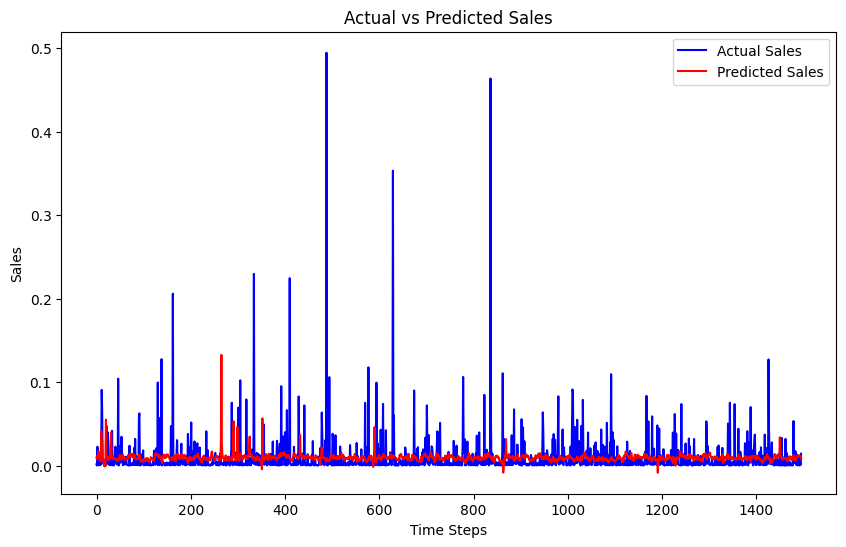

In [20]:
import matplotlib.pyplot as plt

# Compare predictions and actuals
plt.figure(figsize=(10, 6))
plt.plot(range(len(test_targets)), test_targets, label='Actual Sales', color='blue')
plt.plot(range(len(test_targets)), predictions, label='Predicted Sales', color='red')
plt.xlabel('Time Steps')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate on test data
test_loss, test_mae = model.evaluate(test_sequences, test_targets, verbose=1)

# Predict on test data
test_predictions = model.predict(test_sequences)

# Convert predictions to a 1D array for easier metric calculation
test_predictions = test_predictions.flatten()
test_targets = test_targets.flatten()

# Additional metrics
mae = mean_absolute_error(test_targets, test_predictions)
mse = mean_squared_error(test_targets, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_targets, test_predictions)

# Print results
print(f"Test Loss: {test_loss}")
print(f"Test MAE (Keras): {test_mae}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0455e-04 - mae: 0.0124
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Loss: 0.0007611631881445646
Test MAE (Keras): 0.011869026347994804
Mean Absolute Error (MAE): 0.011869025266118959
Mean Squared Error (MSE): 0.0007611630832204762
Root Mean Squared Error (RMSE): 0.02758918417098404
R-squared (R2): -0.03796146776222109
